# Customer Churn Prediction

## Business Problem: 

Telecom/SaaS subscription company

###  Objective:

Predict whether an existing customer is likely to churn and identify the factors contributing to churn.

### Dataset

IBM Telco Customer Churn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv(r"C:\Users\Hp\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
df.tail(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
numerical_cols = df.select_dtypes(include=['int64','float64'])
categorical_cols = df.select_dtypes(include='object')

In [ ]:
print("Numercial Values Columns : ", numerical_cols.columns)

Numercial Values Columns :  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [ ]:
print("Categorical Valus Columns : ", categorical_cols.columns)

Categorical Valus Columns :  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [ ]:
print("Target Varieble is imbanced")
df['Churn'].value_counts()

Target Varieble is imbanced


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## EDA

###  1. Contract type ka churn par kya effect hai?
* One year
* Two year
* Month-to-Month

###  Contract Type:
   * Month-to-month customers have the highest churn rate (42.71%),
   * while two-year contract customers have the lowest churn rate (2.83%).

In [ ]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")*100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
contract_churn_rate = contract_churn["Yes"]

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

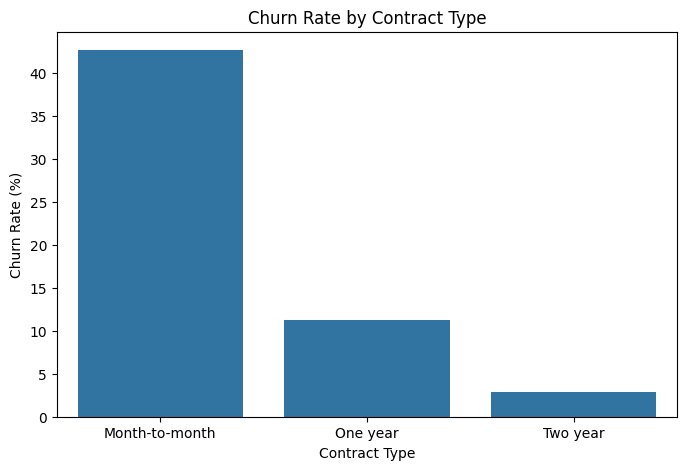

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(x=contract_churn_rate.index, y=contract_churn_rate.values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
print("Churn rate by contract type:")
print(contract_churn_rate)

Churn rate by contract type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64


## 2. Monthly charges badhne par churn increase hota hai?
### Monthly Charges:
   * Churned customers have higher average monthly charges (74.44)
   * compared with non-churned customers (61.27).

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()  # Average monthly charges

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

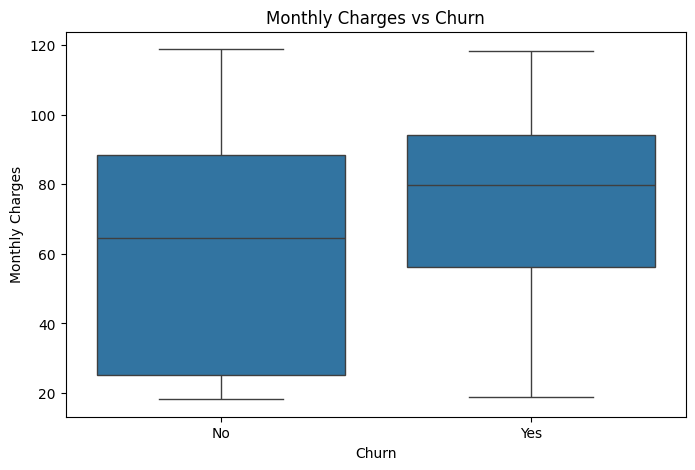

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

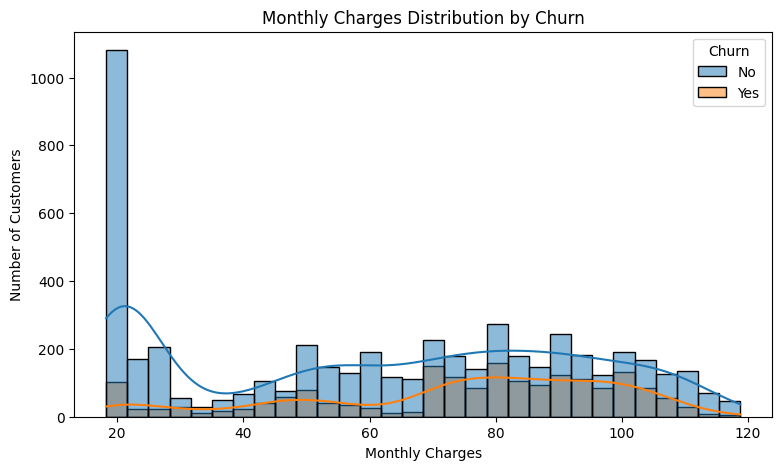

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True, bins=30)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
monthly_charges = df.groupby("Churn")["MonthlyCharges"].mean()

print(monthly_charges)

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


## 3. Tenure aur churn ke beech relationship kya hai?
### Tenure:
   * Shorter-tenure customers generally show higher churn,
   * indicating that customer retention tends to improve with tenure.

In [ ]:
df.groupby("Churn")["tenure"].mean() # Average tenure

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

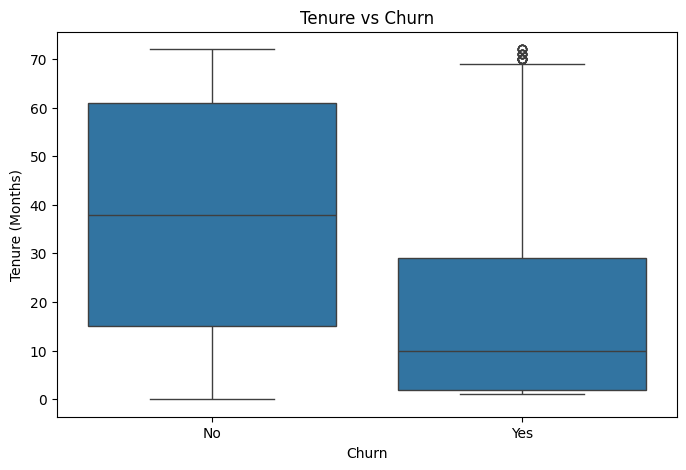

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [ ]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72], labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"])

df[["tenure", "TenureGroup"]].head()

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months


In [ ]:
tenure_churn = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


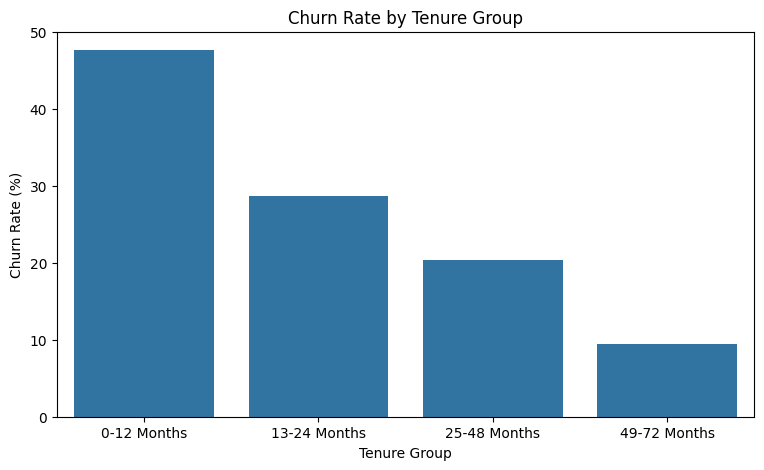

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(x=tenure_churn.index, y=tenure_churn["Yes"].values)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [ ]:
print("Churn rate by tenure group:")
print(tenure_churn["Yes"])

Churn rate by tenure group:
TenureGroup
0-12 Months     47.678161
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Yes, dtype: float64


## 4. Kaunsi payment method wale customers mein churn zyada hai?
### Payment Method:
   * Electronic check customers have the highest churn rate (45.29%),
   * while automatic bank transfer and credit card customers have
   * substantially lower churn rates.

In [ ]:
# Payment method vs churn
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
payment_churn_rate = payment_churn["Yes"]

payment_churn_rate

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Yes, dtype: float64

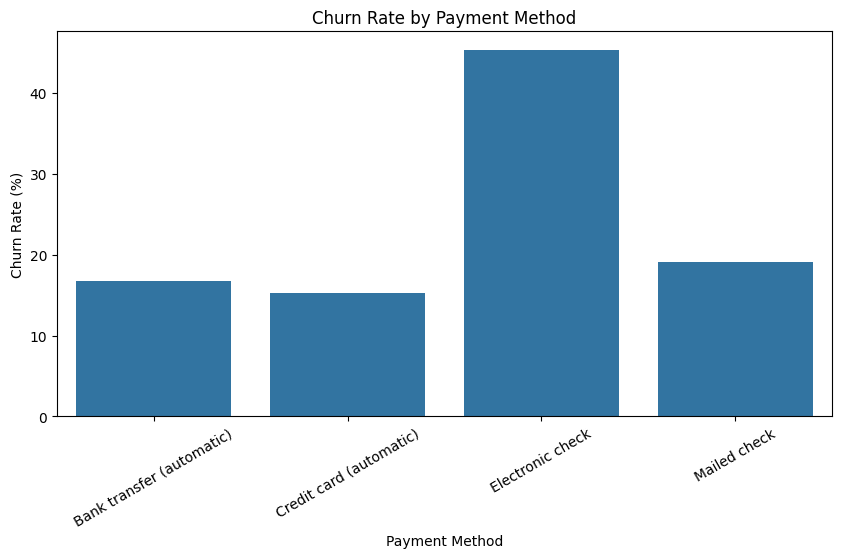

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(x=payment_churn_rate.index, y=payment_churn_rate.values)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [ ]:
payment_churn_rate.sort_values(ascending=False)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64

## 5. Internet service type ka churn par kya effect hai?
### Internet Service:
   * Fiber optic customers have the highest churn rate (~41.88%),
   * followed by DSL (~18.97%), while customers without internet
   * service have the lowest churn rate (~7.41%).

In [ ]:
# Internet Service vs Churn
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
internet_churn_rate = internet_churn["Yes"]

internet_churn_rate

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Yes, dtype: float64

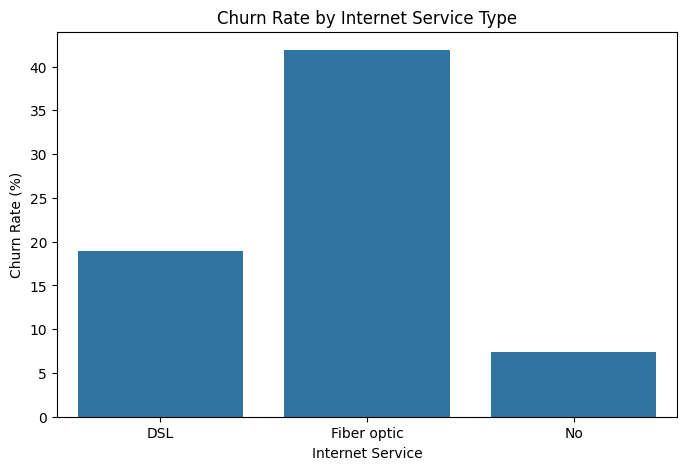

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(x=internet_churn_rate.index, y=internet_churn_rate.values)

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

In [ ]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [ ]:
for i in categorical_cols:
    df[i].value_counts()
    print()
    print()

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months


In [ ]:
# labelencoder -> MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, 
                # Contract,  PaymentMethod

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].dtypes

dtype('float64')

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df.to_csv(r"C:\Users\Hp\Downloads\churn_cleaned_data.csv", index=False)

In [ ]:
df.drop('customerID', axis=1, inplace=True)
categorical_cols.drop('customerID', axis=1, inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
cat_cols = df.select_dtypes(include='object')

In [ ]:
for i in cat_cols:
    print(df[i].value_counts())
    print()
    print()

gender
Male      3555
Female    3488
Name: count, dtype: int64


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


StreamingTV
No       

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
feature_cols = df.select_dtypes(include='object').columns

for col in feature_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0,0-12 Months
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0,25-48 Months
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,0-12 Months
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0,25-48 Months
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,0-12 Months


In [ ]:
df['TenureGroup'].dtypes

CategoricalDtype(categories=['0-12 Months', '13-24 Months', '25-48 Months',
                  '49-72 Months'],
, ordered=True, categories_dtype=object)

In [ ]:
df['TenureGroup'] = le.fit_transform(df['TenureGroup'])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0,2
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,0
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0,2
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,0


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()

In [ ]:
features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                'Contract', 'PaymentMethod', 'PaymentMethod'	,'MonthlyCharges','TotalCharges'	,'TenureGroup', 'tenure']

X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

In [ ]:
X_train.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup
3738,1,0,0,0,0.102371,0,0.055253,-1.183116,-0.919558,-1.040535,1.240874,-0.927928,1.135445,1.131819,-0.827774,0,0.400933,-0.521976,-0.263289,0.357677
3151,1,0,1,1,-0.711743,1,-0.999989,0.174179,1.403666,-1.040535,-1.029696,-0.927928,-1.122619,-1.126208,-0.827774,0,1.336278,0.337478,-0.504814,-0.457843
4860,1,0,1,1,-0.793155,0,0.055253,-1.183116,1.403666,1.227308,-1.029696,1.389424,-1.122619,-1.126208,1.569389,0,1.336278,-0.809013,-0.751213,-0.457843


In [ ]:
X_test.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup
437,1,0,1,1,1.608483,1,1.110496,0.174179,1.403666,1.227308,1.240874,1.389424,1.135445,1.131819,1.569389,1,-0.534412,1.629976,2.707614,1.173197
2280,0,1,0,0,-0.996684,1,1.110496,0.174179,-0.919558,-1.040535,-1.029696,1.389424,1.135445,1.131819,-0.827774,1,-0.534412,1.168725,-0.611505,-1.273363
2235,0,0,1,1,0.346606,1,1.110496,-1.183116,1.403666,1.227308,1.240874,-0.927928,1.135445,-1.126208,0.370807,1,-0.534412,0.445324,0.399490,0.357677


In [ ]:
y_train.head(3)

3738    0
3151    0
4860    0
Name: Churn, dtype: int32

In [ ]:
 y_test.head(3)

437     0
2280    0
2235    0
Name: Churn, dtype: int32

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
# Create models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB() }

In [ ]:
# Store results
results = []

# Train and evaluate models
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append({"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1, "ROC-AUC": roc_auc})

# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort by F1 Score
results_df = results_df.sort_values(by="F1 Score", ascending=False)

C:\Users\Hp\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Hp\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Hp\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Hp\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Hp\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Naive Bayes,0.745919,0.514652,0.751337,0.610870,0.822904
0,Logistic Regression,0.795600,0.636076,0.537433,0.582609,0.839660
2,SVM,0.794180,0.651079,0.483957,0.555215,0.782255
4,Random Forest,0.787083,0.628472,0.483957,0.546828,0.821543
1,KNN,0.761533,0.556213,0.502674,0.528090,0.770859
3,Decision Tree,0.728886,0.489796,0.513369,0.501305,0.659844


## Select Model based on the ROC-AUC

In [ ]:
best_model_name = results_df.loc[0, "Model"]

best_model = models[best_model_name]

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression


## Confusion Matrix

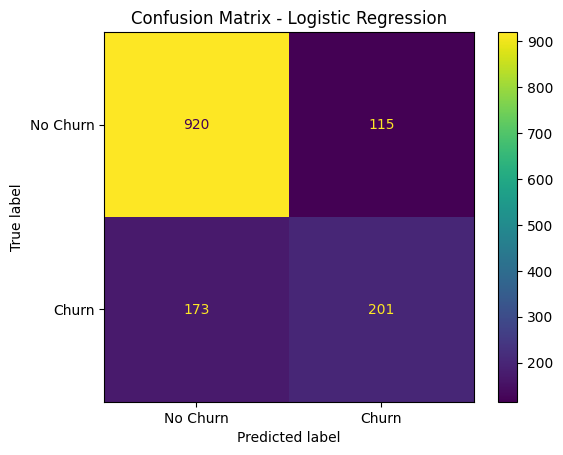

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

disp.plot()

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [ ]:
print('Confusion Martrix')
print(cm)

Confusion Martrix
[[920 115]
 [173 201]]


## Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## ROC Curve for all models

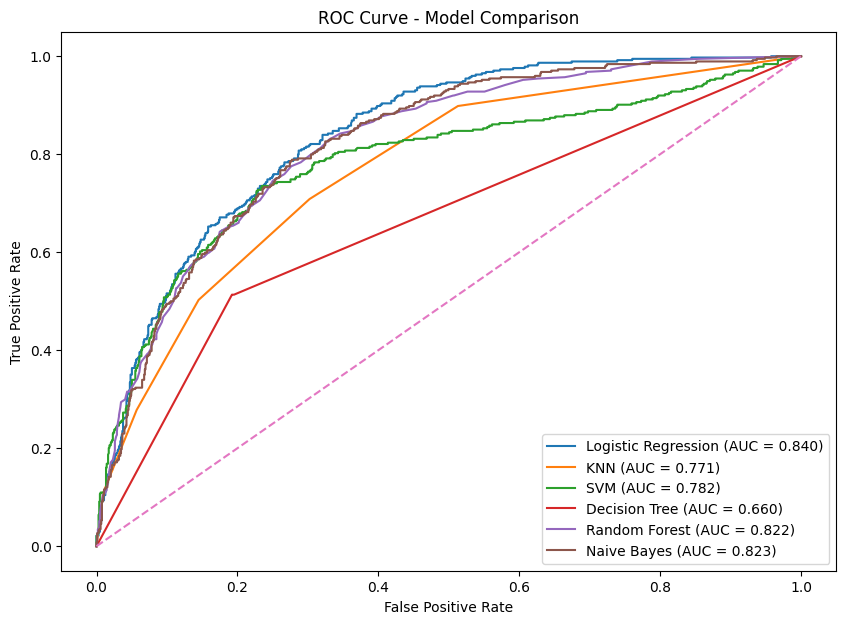

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.show()

## Check Feature Importance

In [ ]:
importance = pd.DataFrame({"Feature": X_train.columns, "Coefficient": best_model.coef_[0]})

importance["Importance"] = importance["Coefficient"].abs()

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Coefficient,Importance
4,tenure,-0.970997,0.970997
5,PhoneService,-0.953753,0.953753
17,MonthlyCharges,0.742018,0.742018
14,Contract,-0.614013,0.614013
18,TotalCharges,0.437468,0.437468
15,PaperlessBilling,0.393236,0.393236
8,OnlineSecurity,-0.247479,0.247479
3,Dependents,-0.233921,0.233921
11,TechSupport,-0.227250,0.227250
19,TenureGroup,-0.194857,0.194857


<Figure size 300x300 with 0 Axes>

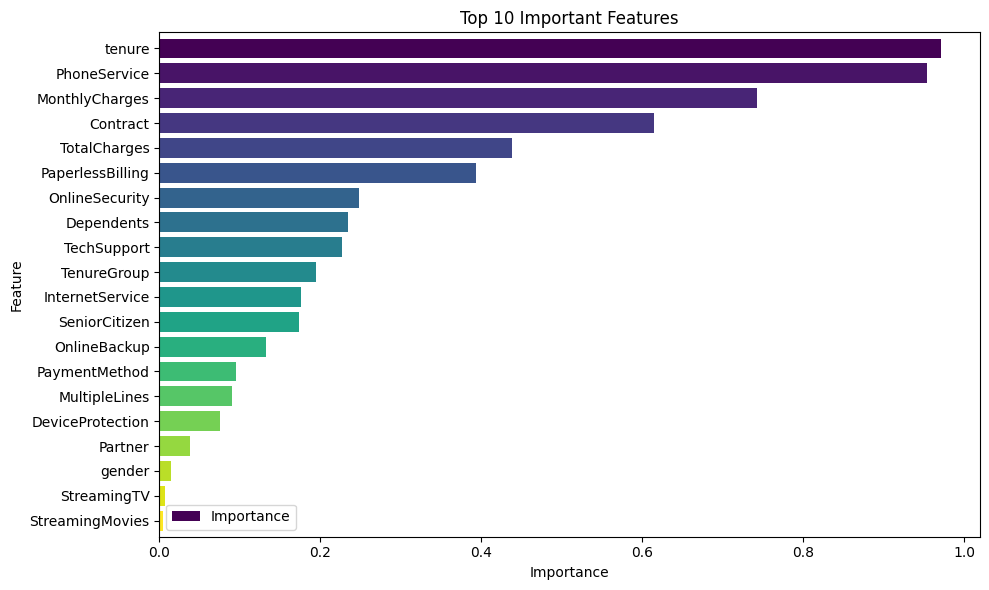

In [ ]:
colors = plt.cm.viridis(np.linspace(0, 1, len(importance)))

plt.figure(figsize=(3,3))

importance.plot(x="Feature", y="Importance", kind="barh", figsize=(10, 6), color=colors, width=0.8)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']

## Conclusion

##### The analysis shows that **contract type, monthly charges, tenure, payment method, and internet service** are important factors related to customer churn. Month-to-month customers, customers with higher monthly charges, short-tenure customers, electronic-check users, and fiber-optic users showed higher churn rates. The machine learning model can help identify high-risk customers and support the business in taking **early retention actions**.
